In [12]:
# Update paths if needed
input_dir <- "plots_alphagenome_ISM_Intron4/"
output_dir <- "plots_alphagenome_ISM_Intron4/complementary_motif_analysis"
min_size <- 5L
max_size <- 500L
top_curves <- 5L
set.seed(42)
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

In [13]:
## Install missing packages
if (!requireNamespace("BiocManager", quietly = TRUE)) {
    install.packages("BiocManager", repos = "https://cloud.r-project.org")
}

#install.packages("ggplot2", repos = "https://cloud.r-project.org")
#install.packages("ggseqlogo", repos = "https://cloud.r-project.org")
#install.packages("pheatmap", repos = "https://cloud.r-project.org")
#install.packages("gridExtra", repos = "https://cloud.r-project.org")

#BiocManager::install("clusterProfiler", ask = FALSE, update = FALSE)
#BiocManager::install("enrichplot", ask = FALSE, update = FALSE)
#BiocManager::install("fgsea", ask = FALSE, update = FALSE)

In [14]:
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggseqlogo)
library(pheatmap)

In [15]:
safe_name <- function(x) gsub("[^A-Za-z0-9_.-]+", "_", x)

read_rnk <- function(path) {
  x <- read.delim(path, header = FALSE, sep = "\t", stringsAsFactors = FALSE)
  colnames(x) <- c("motif", "score")
  x$motif <- toupper(x$motif)
  x$score <- as.numeric(x$score)
  x <- x[!is.na(x$motif) & !is.na(x$score), , drop = FALSE]
  x <- x[order(x$score, decreasing = TRUE), , drop = FALSE]
  x
}

read_gmt_to_term2gene <- function(path) {
  lines <- readLines(path, warn = FALSE)
  rows <- vector("list", length(lines))
  for (i in seq_along(lines)) {
    parts <- strsplit(lines[[i]], "\t", fixed = TRUE)[[1]]
    if (length(parts) < 4) next
    term <- parts[1]
    genes <- toupper(parts[3:length(parts)])
    genes <- genes[nzchar(genes)]
    if (length(genes) == 0) next
    rows[[i]] <- data.frame(term = term, gene = genes, stringsAsFactors = FALSE)
  }
  do.call(rbind, rows)
}

write_core_enrichment_heatmap <- function(gsea_df, out_png, n_sets = 12, top_motifs = 10, padj_cutoff = 0.05) {
  gsea_df <- gsea_df[gsea_df$p.adjust < padj_cutoff, , drop = FALSE]
  gsea_df <- gsea_df[order(gsea_df$p.adjust, -gsea_df$NES), , drop = FALSE]
  if (nrow(gsea_df) == 0) {
    message("No significant motif sets at p.adjust < ", padj_cutoff, "; skipping heatmap.")
    return(invisible(NULL))
  }

  sel <- head(gsea_df, n_sets)
  split_core <- strsplit(sel$core_enrichment, "/", fixed = TRUE)
  all_core <- unlist(split_core, use.names = FALSE)
  all_core <- all_core[nzchar(all_core)]
  top <- names(sort(table(all_core), decreasing = TRUE))
  top <- head(top, top_motifs)
  if (length(top) == 0) return(invisible(NULL))

  mat <- matrix(0, nrow = length(top), ncol = nrow(sel))
  rownames(mat) <- top
  colnames(mat) <- sel$ID
  for (j in seq_len(nrow(sel))) {
    s <- unique(split_core[[j]])
    s <- s[nzchar(s)]
    mat[, j] <- as.integer(top %in% s)
  }

  pheatmap(
    mat,
    cluster_rows = TRUE,
    cluster_cols = FALSE,
    color = colorRampPalette(c("white", "#f5a836"))(100),
    main = "Leading-edge motif overlap (R)",
    filename = out_png,
    width = max(8, ncol(mat) * 0.7),
    height = max(6, nrow(mat) * 0.22)
  )
}

write_logo <- function(gsea_df, out_png, n_sets = 5, top_motifs = 40) {
  pos <- gsea_df[gsea_df$NES > 0, , drop = FALSE]
  pos <- pos[order(pos$p.adjust), , drop = FALSE]
  pos <- head(pos, n_sets)
  cores <- unlist(strsplit(pos$core_enrichment, "/", fixed = TRUE), use.names = FALSE)
  cores <- cores[nzchar(cores)]
  top <- names(sort(table(cores), decreasing = TRUE))
  top <- head(top, top_motifs)
  lens <- table(nchar(top))
  if (length(lens) == 0) return(invisible(NULL))
  mode_len <- as.integer(names(lens)[which.max(lens)])
  top <- top[nchar(top) == mode_len]
  if (length(top) < 3) return(invisible(NULL))

  p <- ggseqlogo(top, method = "prob") +
    ggtitle("Top leading-edge motif logo (R)") +
    theme_bw(base_size = 11)
  ggsave(out_png, p, width = 10, height = 3.8, dpi = 220)
}

In [16]:
rnk_path <- file.path(input_dir, "motif_scores.rnk")
gmt_path <- file.path(input_dir, "motif_sets.gmt")
stopifnot(file.exists(rnk_path), file.exists(gmt_path))

rnk_df <- read_rnk(rnk_path)
term2gene <- unique(read_gmt_to_term2gene(gmt_path))

gene_list <- rnk_df$score
names(gene_list) <- rnk_df$motif
gene_list <- sort(gene_list, decreasing = TRUE)

head(rnk_df)

,motif,score
,<chr>,<dbl>
1,TAAGTTT,0.999996
2,CTACGTC,0.999990
3,CTTCGAA,0.999984
4,GCTCGGT,0.999978
5,TGCGAGG,0.999971
6,ATGGTAG,0.999951


In [17]:
gsea_res <- GSEA(
  geneList = gene_list,
  TERM2GENE = term2gene,
  minGSSize = min_size,
  maxGSSize = max_size,
  pvalueCutoff = 1,
  pAdjustMethod = "BH",
  eps = 0,
  seed = TRUE,
  by = "fgsea"
)

stopifnot(!is.null(gsea_res), nrow(gsea_res@result) > 0)
gsea_df <- gsea_res@result
gsea_df <- gsea_df[order(gsea_df$p.adjust, -gsea_df$NES), , drop = FALSE]
head(gsea_df[, c("ID", "setSize", "enrichmentScore", "NES", "p.adjust")], 10)

using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (48.98% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“All values in the stats vector are greater than zero and scoreType is "std", maybe you should switch to scoreType = "pos".”
leading edge analysis...

done...



,ID,setSize,enrichmentScore,NES,p.adjust
,<chr>,<int>,<dbl>,<dbl>,<dbl>
CGG,CGG,10,0.7901723,2.624757,0.0001233131
ACG,ACG,10,0.7323767,2.432774,0.0007114083
CG-core,CG-core,39,0.4471817,2.383782,0.0007114083
CTA,CTA,33,0.4132126,2.094512,0.0151187472
GAC,GAC,11,0.5762267,2.004426,0.0354779255
CTG,CTG,16,0.4430355,1.774039,0.1376749694
CGA,CGA,12,0.4150838,1.496631,0.4706994310
CCA,CCA,16,-0.3035710,-1.456473,0.4706994310
TCG,TCG,19,0.3498419,1.487091,0.4865853659


In [18]:
write.csv(gsea_df, file.path(output_dir, "gsea_results_r.csv"), row.names = FALSE)
write.csv(subset(gsea_df, p.adjust < 0.25), file.path(output_dir, "gsea_significant_sets_r.csv"), row.names = FALSE)

top_enriched <- head(gsea_df[gsea_df$NES > 0, , drop = FALSE][order(gsea_df[gsea_df$NES > 0, , drop = FALSE]$p.adjust), ], 10)
top_depleted <- head(gsea_df[gsea_df$NES < 0, , drop = FALSE][order(gsea_df[gsea_df$NES < 0, , drop = FALSE]$p.adjust), ], 10)

write.csv(top_enriched, file.path(output_dir, "gsea_top_enriched_sets_r.csv"), row.names = FALSE)
write.csv(top_depleted, file.path(output_dir, "gsea_top_depleted_sets_r.csv"), row.names = FALSE)

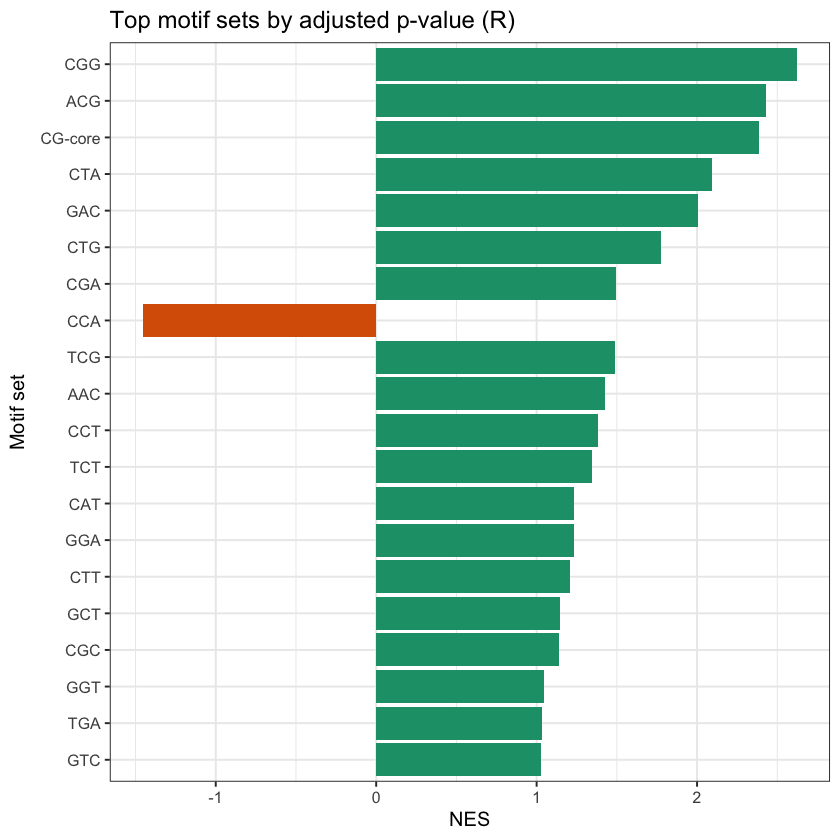

In [19]:
top20 <- head(gsea_df, 20)
top20$ID <- factor(top20$ID, levels = rev(top20$ID))
p_nes <- ggplot(top20, aes(x = ID, y = NES, fill = NES >= 0)) +
  geom_col() +
  coord_flip() +
  theme_bw(base_size = 12) +
  labs(title = "Top motif sets by adjusted p-value (R)", x = "Motif set", y = "NES") +
  scale_fill_manual(values = c("TRUE" = "#1b9e77", "FALSE" = "#d95f02"), guide = "none")

print(p_nes)
ggsave(file.path(output_dir, "gsea_top_sets_nes_r.png"), p_nes, width = 9, height = 6, dpi = 300)

In [ ]:
top_pos <- head(gsea_df[gsea_df$NES > 0, , drop = FALSE][order(gsea_df[gsea_df$NES > 0, , drop = FALSE]$p.adjust), ], top_curves)
top_neg <- head(gsea_df[gsea_df$NES < 0, , drop = FALSE][order(gsea_df[gsea_df$NES < 0, , drop = FALSE]$p.adjust), ], top_curves)

for (i in seq_len(nrow(top_pos))) {
  nm <- top_pos$ID[i]
  p <- gseaplot2(gsea_res, geneSetID = nm, title = paste0(nm, " (enriched)"), pvalue_table = TRUE, pvalue_table_columns = c("NES", "p.adjust"), pvalue_table_rownames = "ID")
  print(p)
  ggsave(file.path(output_dir, paste0("gsea_curve_enriched_", safe_name(nm), "_r.png")), p, width = 6, height = 4, dpi = 300)
}

for (i in seq_len(nrow(top_neg))) {
  nm <- top_neg$ID[i]
  p <- gseaplot2(gsea_res, geneSetID = nm, title = paste0(nm, " (depleted)"), pvalue_table = TRUE, pvalue_table_columns = c("NES", "p.adjust"), pvalue_table_rownames = "ID")
  print(p)
  ggsave(file.path(output_dir, paste0("gsea_curve_depleted_", safe_name(nm), "_r.png")), p, width = 6, height = 4, dpi = 300)
}

In [21]:
write_core_enrichment_heatmap(
  gsea_df = gsea_df,
  out_png = file.path(output_dir, "leading_edge_membership_heatmap_r.png"),
  n_sets = 12,
  top_motifs = 40
)

In [22]:
out_files <- list.files(output_dir, pattern = "_r\\.(csv|png)$", full.names = FALSE)
out_files

[1] "gsea_curve_depleted_AGC_r.png"        
 [2] "gsea_curve_depleted_CCA_r.png"        
 [3] "gsea_curve_depleted_GGC_r.png"        
 [4] "gsea_curve_depleted_GTA_r.png"        
 [5] "gsea_curve_depleted_TCA_r.png"        
 [6] "gsea_curve_enriched_ACG_r.png"        
 [7] "gsea_curve_enriched_CG-core_r.png"    
 [8] "gsea_curve_enriched_CGG_r.png"        
 [9] "gsea_curve_enriched_CTA_r.png"        
[10] "gsea_curve_enriched_GAC_r.png"        
[11] "gsea_results_r.csv"                   
[12] "gsea_significant_sets_r.csv"          
[13] "gsea_top_depleted_sets_r.csv"         
[14] "gsea_top_enriched_sets_r.csv"         
[15] "gsea_top_sets_nes_r.png"              
[16] "leading_edge_membership_heatmap_r.png"